In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
from torchvision.models import resnet50
import cv2
import numpy as np
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
import flask
from flask import Flask, Response, render_template_string
import threading
import time
import psutil
import GPUtil

In [2]:
# GPU Verification
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA version:", torch.version.cuda)
    print("GPU device name:", torch.cuda.get_device_name(0))
    device = torch.device('cuda')
else:
    print("CUDA not available, using CPU")
    device = torch.device('cpu')

# Mixed precision
scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None

PyTorch version: 2.12.0.dev20260408+cu128
CUDA available: True
CUDA version: 12.8
GPU device name: NVIDIA GeForce RTX 5050 Laptop GPU


C:\Users\Llywellyn Sana\AppData\Local\Temp\ipykernel_23676\1131257919.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None


In [3]:
# Dataset Loading
import os
from torch.utils.data import Dataset
from PIL import Image
import torchvision.transforms as transforms

class BDD100KDataset(Dataset):
    def __init__(self, root_dir, split='train', transform=None):
        self.root_dir = os.path.join(root_dir, split,'images')
        self.transform = transform
        self.image_files = [f for f in os.listdir(self.root_dir) if f.endswith('.jpg')]

    def __len__(self):
        return len(self.image_files)

    def __getitem__(self, idx):
        img_path = os.path.join(self.root_dir, self.image_files[idx])
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        # For simplicity, no labels, just images
        return image, img_path

# Transforms
transform = transforms.Compose([
    transforms.Resize((640, 640)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Datasets
train_dataset = BDD100KDataset('100k', 'train', transform)
val_dataset = BDD100KDataset('100k','val', transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=4, pin_memory=True)

In [4]:
# Object Detection Model: YOLOv8
from ultralytics import YOLO

# Load pre-trained YOLOv8 nano model
yolo_model = YOLO('yolov8n.pt')

# Move to GPU if available
if torch.cuda.is_available():
    yolo_model.to(device)

In [5]:
# Lane Detection with OpenCV
def detect_lanes(image):
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Apply Gaussian blur
    blur = cv2.GaussianBlur(gray, (5, 5), 0)
    # Canny edge detection
    edges = cv2.Canny(blur, 50, 150)
    # Define region of interest (bottom half for lanes)
    height, width = edges.shape
    mask = np.zeros_like(edges)
    polygon = np.array([[(0, height), (width, height), (width//2, height//2)]], np.int32)
    cv2.fillPoly(mask, polygon, 255)
    masked_edges = cv2.bitwise_and(edges, mask)
    # Hough line detection
    lines = cv2.HoughLinesP(masked_edges, 1, np.pi/180, 50, minLineLength=50, maxLineGap=150)
    return lines

In [6]:
# Path Planning
def plan_path(objects, lanes):
    # Simple rule: avoid obstacles, stay in lane
    # For demo, just return a direction
    if objects:
        # If objects detected, steer away
        return "turn_left"
    elif lanes:
        # Follow lanes
        return "go_straight"
    else:
        return "stop"


0: 384x640 2 cars, 1 truck, 3 traffic lights, 48.6ms
Speed: 33.6ms preprocess, 48.6ms inference, 33.6ms postprocess per image at shape (1, 3, 384, 640)
Detected objects: 6
Detected lanes: True
Action: turn_left


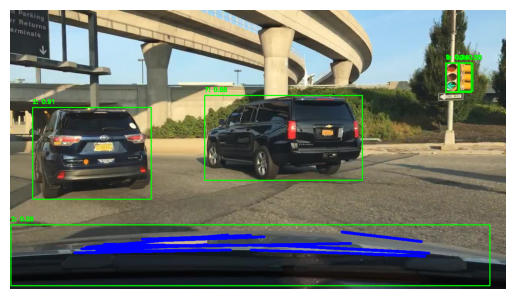

In [7]:
# Inference Pipeline
def process_frame(frame):
    # Object detection
    results = yolo_model(frame)
    objects = results[0].boxes.data.tolist()  # List of detections

    # Lane detection
    lanes = detect_lanes(frame)

    # Path planning
    action = plan_path(objects, lanes)

    return objects, lanes, action

# Test on a sample image
sample_img_path = os.path.join('100k', 'train','images', train_dataset.image_files[0])
sample_img = cv2.imread(sample_img_path)
objects, lanes, action = process_frame(sample_img)
print("Detected objects:", len(objects))
print("Detected lanes:", lanes is not None)
print("Action:", action)

# Visualize results on the image
output_img = sample_img.copy()

# Draw bounding boxes for objects
for obj in objects:
    x1, y1, x2, y2, conf, cls = obj
    cv2.rectangle(output_img, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    cv2.putText(output_img, f'{int(cls)}: {conf:.2f}', (int(x1), int(y1)-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

# Draw lanes
if lanes is not None:
    for line in lanes:
        x1, y1, x2, y2 = line[0]
        cv2.line(output_img, (x1, y1), (x2, y2), (255, 0, 0), 5)

# Display the image
plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

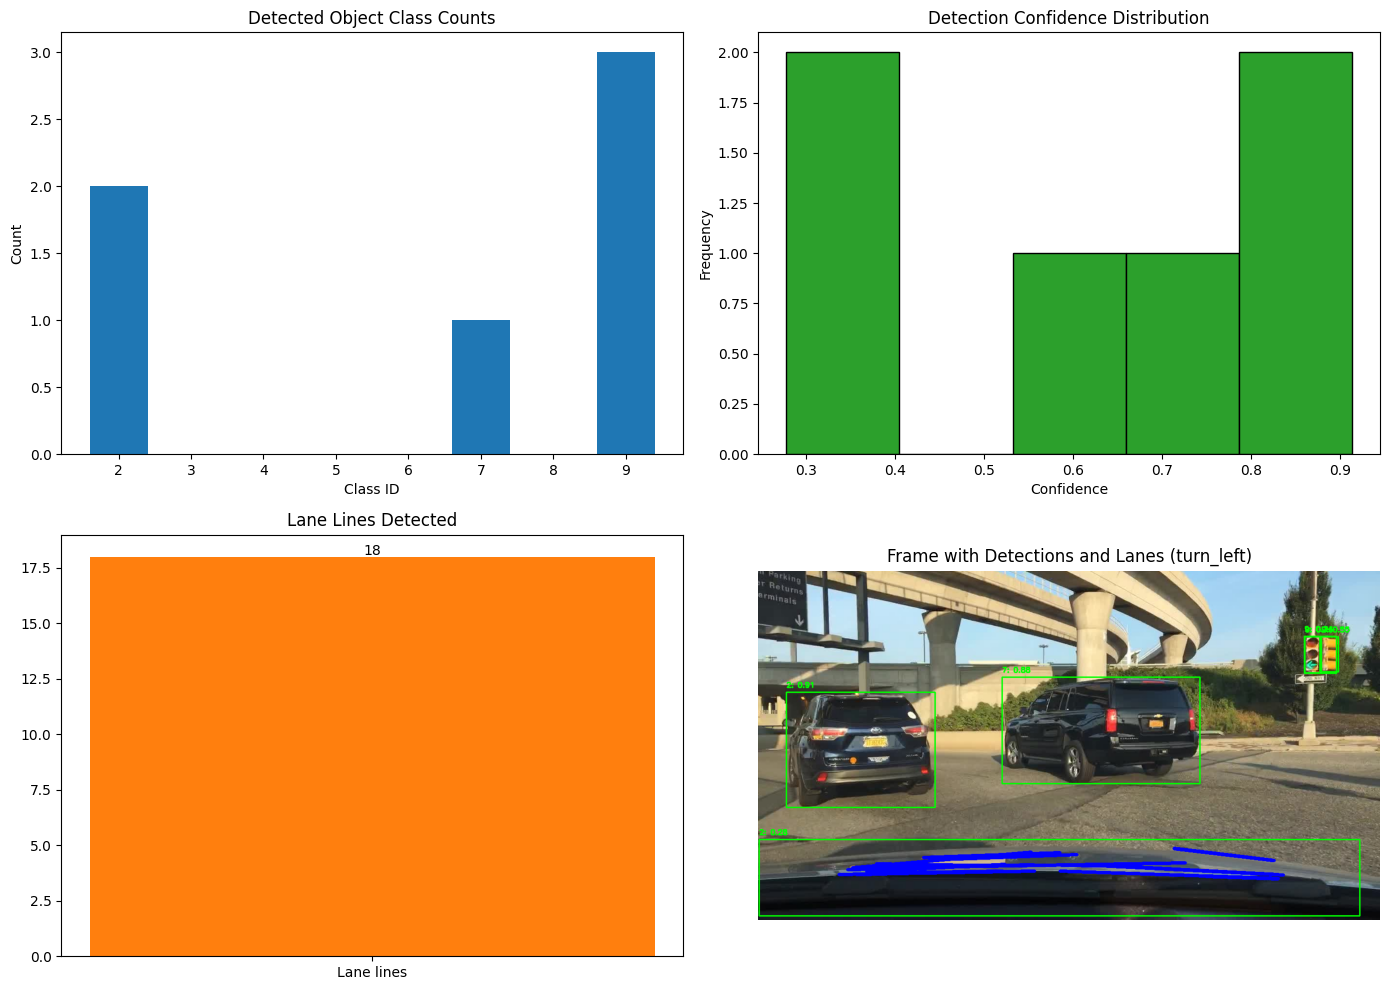

In [8]:
# Plot detection and lane statistics
class_ids = [int(obj[5]) for obj in objects]
confidences = [obj[4] for obj in objects]
class_counts = {}
for cls_id in class_ids:
    class_counts[cls_id] = class_counts.get(cls_id, 0) + 1

lane_count = len(lanes) if lanes is not None else 0

fig, axs = plt.subplots(2, 2, figsize=(14, 10))

# Object class counts
axs[0, 0].bar(class_counts.keys(), class_counts.values(), color='tab:blue')
axs[0, 0].set_title('Detected Object Class Counts')
axs[0, 0].set_xlabel('Class ID')
axs[0, 0].set_ylabel('Count')

# Confidence histogram
axs[0, 1].hist(confidences, bins=5, color='tab:green', edgecolor='black')
axs[0, 1].set_title('Detection Confidence Distribution')
axs[0, 1].set_xlabel('Confidence')
axs[0, 1].set_ylabel('Frequency')

# Lane count
axs[1, 0].bar(['Lane lines'], [lane_count], color='tab:orange')
axs[1, 0].set_title('Lane Lines Detected')
axs[1, 0].set_ylim(0, max(5, lane_count + 1))
for i, v in enumerate([lane_count]):
    axs[1, 0].text(i, v + 0.1, str(v), ha='center')

# Image with detections
axs[1, 1].imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
axs[1, 1].set_title(f'Frame with Detections and Lanes ({action})')
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

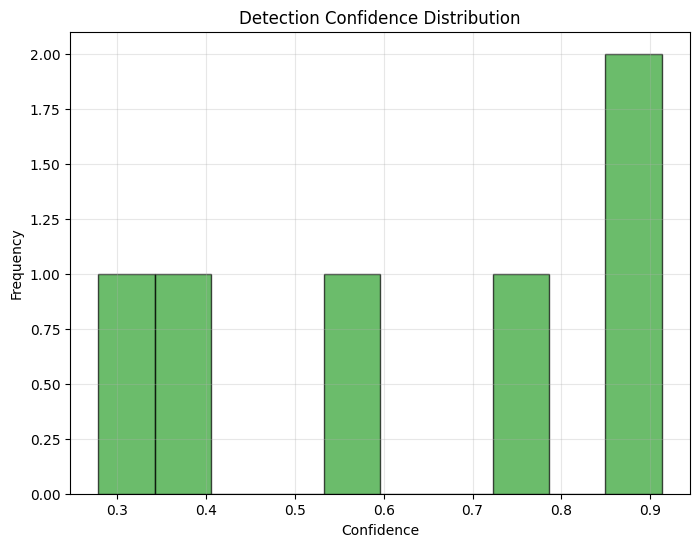

In [9]:
import matplotlib.pyplot as plt

# Plot confidence histogram
plt.figure(figsize=(8, 6))
plt.hist(confidences, bins=10, color='tab:green', edgecolor='black', alpha=0.7)
plt.title('Detection Confidence Distribution')
plt.xlabel('Confidence')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

In [10]:
import os

os.makedirs('data', exist_ok=True)

data_yaml_content = """
path: 100k
train: train/images
val: val/images
nc: 10
names: ['car', 'truck', 'bus', 'motorcycle', 'bicycle', 'person', 'rider', 'traffic light', 'traffic sign', 'train']
"""

with open('data/bdd100k.yaml', 'w') as f:
    f.write(data_yaml_content)

if os.path.exists('yolov8n_trained.pt'):
    print("Trained model already exists, skipping training.")
else:
    yolo_model.train(data='data/bdd100k.yaml', epochs=5, imgsz=512, batch=32, device=device)
    yolo_model.save('yolov8n_trained.pt')

Trained model already exists, skipping training.


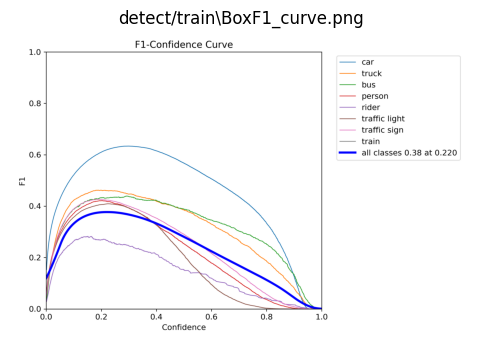

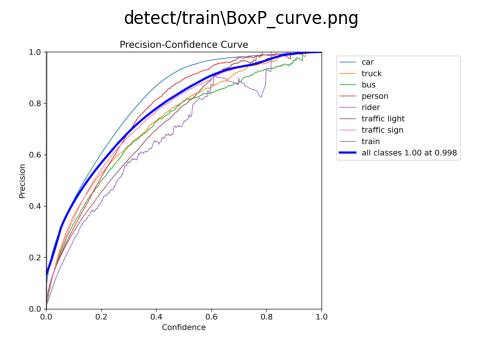

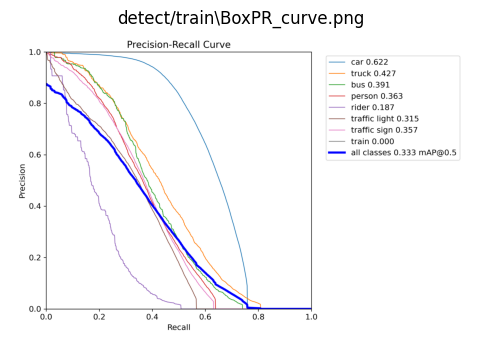

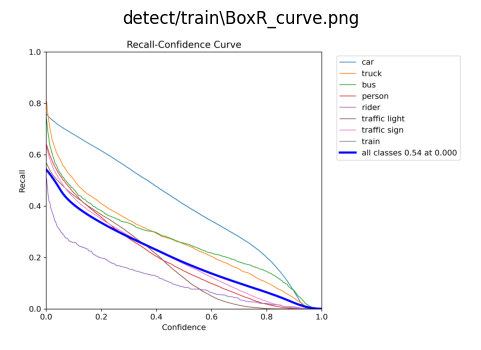

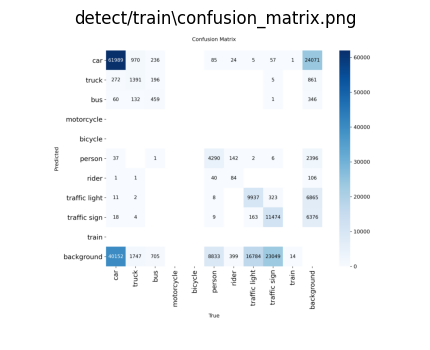

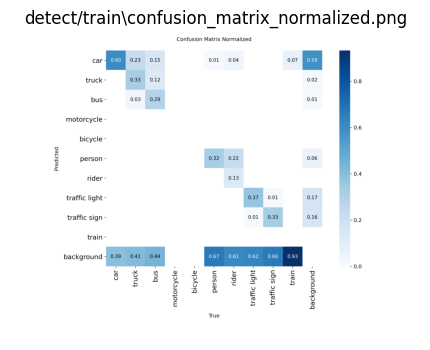

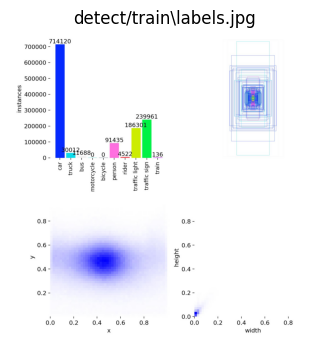

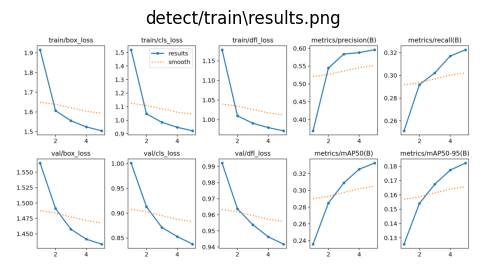

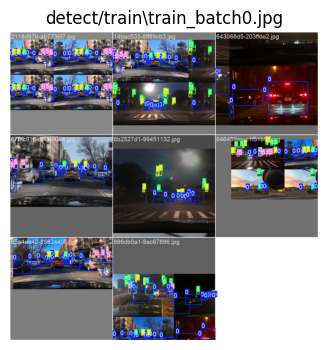

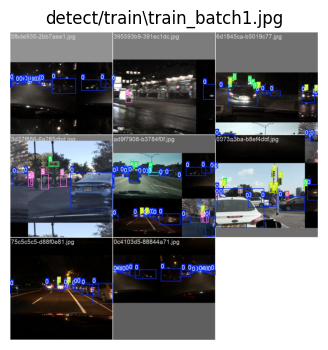

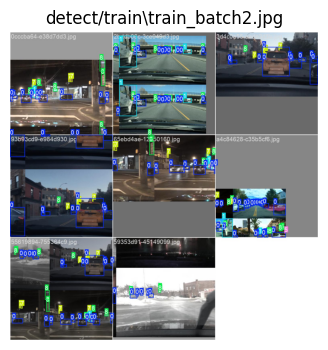

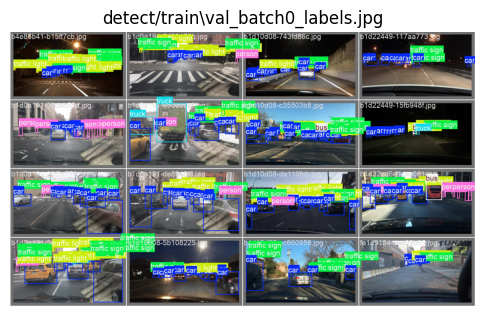

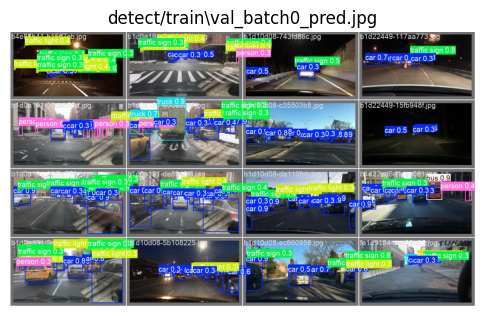

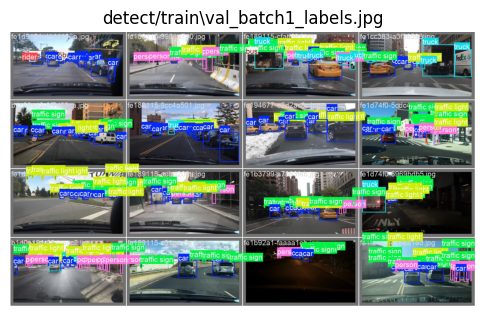

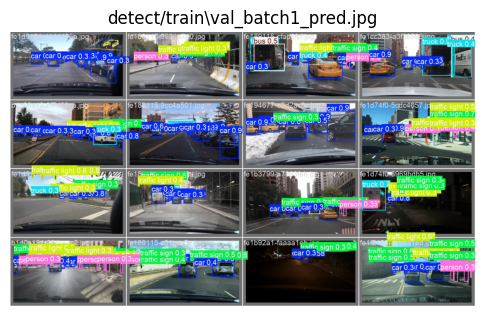

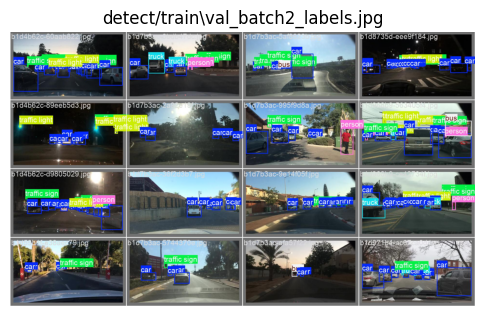

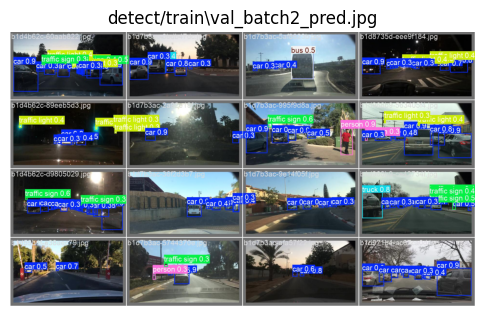


=== Run directory: runs\detect ===
- train\args.yaml (.yaml, 1690 bytes)
- train\BoxF1_curve.png (.png, 247273 bytes)
- train\BoxP_curve.png (.png, 260092 bytes)
- train\BoxPR_curve.png (.png, 275692 bytes)
- train\BoxR_curve.png (.png, 238428 bytes)
- train\confusion_matrix.png (.png, 239208 bytes)
- train\confusion_matrix_normalized.png (.png, 211825 bytes)
- train\labels.jpg (.jpg, 134908 bytes)
- train\results.csv (.csv, 818 bytes)
- train\results.png (.png, 240060 bytes)
- train\train_batch0.jpg (.jpg, 344498 bytes)
- train\train_batch1.jpg (.jpg, 264210 bytes)
- train\train_batch2.jpg (.jpg, 298330 bytes)
- train\val_batch0_labels.jpg (.jpg, 448646 bytes)
- train\val_batch0_pred.jpg (.jpg, 452212 bytes)
- train\val_batch1_labels.jpg (.jpg, 454536 bytes)
- train\val_batch1_pred.jpg (.jpg, 449616 bytes)
- train\val_batch2_labels.jpg (.jpg, 388300 bytes)
- train\val_batch2_pred.jpg (.jpg, 395096 bytes)
- train\weights\best.pt (.pt, 6229226 bytes)
- train\weights\last.pt (.pt, 62292

In [11]:
from pathlib import Path

runs_dir = Path('runs')
text_output = ""
if not runs_dir.exists():
    text_output += "No runs folder found.\n"
else:
    run_dirs = sorted([p for p in runs_dir.iterdir() if p.is_dir()])
    if not run_dirs:
        text_output += "No run directories found inside runs/\n"
    for run_dir in run_dirs:
        text_output += f"\n=== Run directory: {run_dir} ===\n"
        all_files = sorted([p for p in run_dir.rglob('*') if p.is_file()])
        for p in all_files:
            text_output += f"- {p.relative_to(run_dir)} ({p.suffix.lower()}, {p.stat().st_size} bytes)\n"

        image_extensions = {'.png', '.jpg', '.jpeg', '.bmp'}
        text_extensions = {'.txt', '.csv', '.yaml', '.yml', '.json'}

        image_files = [p for p in all_files if p.suffix.lower() in image_extensions]
        if image_files:
            for img_path in image_files:
                img = cv2.imread(str(img_path))
                if img is None:
                    text_output += f"Could not read image: {img_path}\n"
                    continue
                plt.figure(figsize=(6, 4))
                plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
                plt.title(f'{run_dir.name}/{img_path.relative_to(run_dir)}')
                plt.axis('off')
                plt.show()
        else:
            text_output += "No image artifacts found in this run.\n"

        text_files = [p for p in all_files if p.suffix.lower() in text_extensions]
        for txt_path in text_files:
            text_output += f"\n--- {txt_path.relative_to(run_dir)} ---\n"
            try:
                with open(txt_path, 'r', encoding='utf-8', errors='ignore') as f:
                    lines = f.readlines()
                text_output += ''.join(lines[:40])
                if len(lines) > 40:
                    text_output += "\n... (truncated)\n"
            except Exception as e:
                text_output += f"Could not read {txt_path}: {e}\n"

print(text_output)

Selected image: cf56360a-3da87cc3.jpg

0: 384x640 1 person, 5 cars, 1 truck, 10.9ms
Speed: 1.4ms preprocess, 10.9ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

Detected 7 objects:
  - car: confidence 0.92
  - car: confidence 0.92
  - car: confidence 0.82
  - car: confidence 0.81
  - truck: confidence 0.72
  - car: confidence 0.63
  - person: confidence 0.63


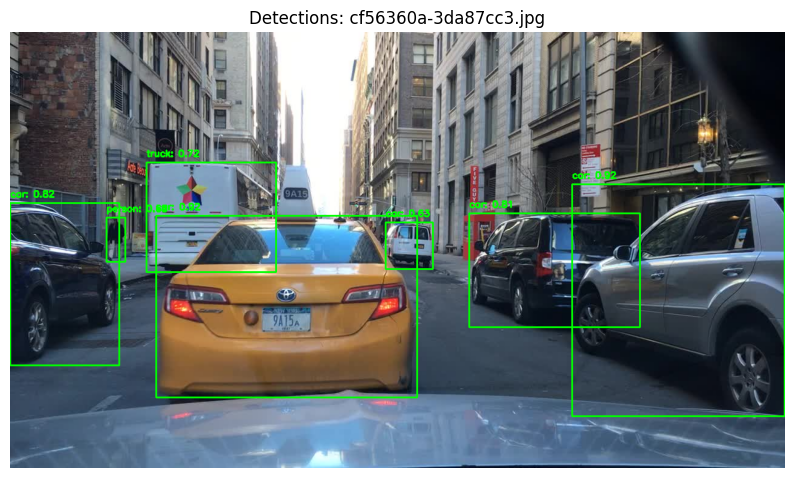

In [12]:
import random
from pathlib import Path

# Get all images from test folder
test_images_dir = Path('100k/test')
test_images = list(test_images_dir.glob('*.jpg'))

# Select a random image
random_img_path = random.choice(test_images)
print(f"Selected image: {random_img_path.name}")

# Read the image
test_img = cv2.imread(str(random_img_path))

# Run inference
results = yolo_model(test_img)
detections = results[0].boxes.data.tolist()

# Display results
print(f"\nDetected {len(detections)} objects:")
for obj in detections:
    x1, y1, x2, y2, conf, cls = obj
    class_name = results[0].names[int(cls)]
    print(f"  - {class_name}: confidence {conf:.2f}")

# Visualize
output = test_img.copy()
for obj in detections:
    x1, y1, x2, y2, conf, cls = obj
    class_name = results[0].names[int(cls)]
    cv2.rectangle(output, (int(x1), int(y1)), (int(x2), int(y2)), (0, 255, 0), 2)
    cv2.putText(output, f'{class_name}: {conf:.2f}', (int(x1), int(y1)-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f'Detections: {random_img_path.name}')
plt.axis('off')
plt.show()